In [ ]:
import pandas as pd 
import matplotlib.pyplt as plt
import seaborn as sns

In [ ]:
! pip install pandas matplotlib seaborn  

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('superstore_sales.csv')
df.head()

In [5]:
df = pd.read_csv('superstore.csv')
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Data Types:
 Category              str
City                  str
Country               str
Customer.ID           str
Customer.Name         str
Discount          float64
Market                str
记录数                 int64
Order.Date            str
Order.ID              str
Order.Priority        str
Product.ID            str
Product.Name          str
Profit            float64
Quantity            int64
Region                str
Row.ID              int64
Sales               int64
Segment               str
Ship.Date             str
Ship.Mode             str
Shipping.Cost     float64
State                 str
Sub.Category          str
Year                int64
Market2               str
weeknum             int64
dtype: object

Missing Values:
 Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name

In [9]:
import pandas as pd
df =pd.read_csv('superstore.csv')

num_stats =df.describe().T[["mean","50%","std"]]
num_stats.rename(columns={"50%":"median"}, inplace=True)

num_stats["mode"] = df[df.select_dtypes(include="number").columns].mode().iloc[0]
print("Descriptive Statistics for Numerical Columns:")
display(num_stats[["mean", "median", "std", "mode"]])

Descriptive Statistics for Numerical Columns:


,mean,median,std,mode
Discount,0.142908,0.00,0.212280,0.00
记录数,1.000000,1.00,0.000000,1.00
Profit,28.610982,9.24,174.340972,0.00
Quantity,3.476545,3.00,2.278766,2.00
Row.ID,25645.500000,25645.50,14806.291990,1.00
Sales,246.498440,85.00,487.567175,13.00
Shipping.Cost,26.375818,7.79,57.296810,0.35
Year,2012.777208,2013.00,1.098931,2014.00
weeknum,31.287112,33.00,14.429795,47.00


In [11]:
df.columns


Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert dates
df['Order.Date'] = pd.to_datetime(df['Order.Date'], errors='coerce')
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'], errors='coerce')

# Convert numerical columns
numeric_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping.Cost']

for col in numeric_cols: df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  str           
 1   City            51290 non-null  str           
 2   Country         51290 non-null  str           
 3   Customer.ID     51290 non-null  str           
 4   Customer.Name   51290 non-null  str           
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  str           
 7   记录数             51290 non-null  int64         
 8   Order.Date      51290 non-null  datetime64[us]
 9   Order.ID        51290 non-null  str           
 10  Order.Priority  51290 non-null  str           
 11  Product.ID      51290 non-null  str           
 12  Product.Name    51290 non-null  str           
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Region       

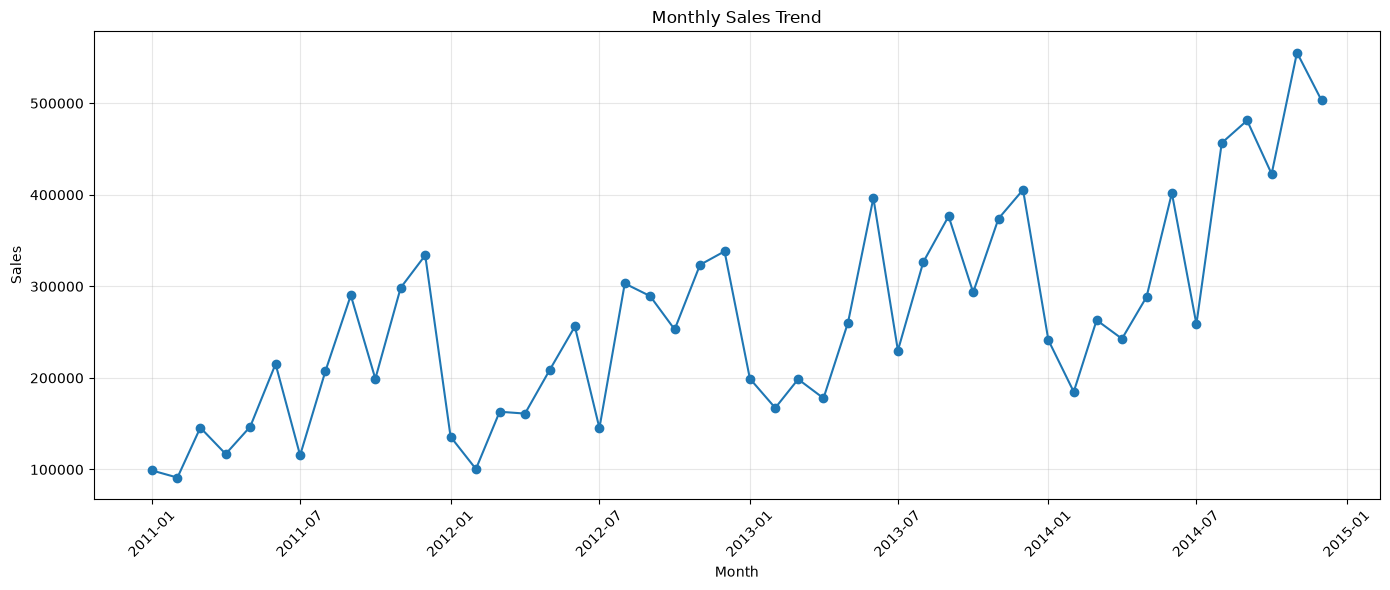

In [14]:
monthly_sales = (
    df.groupby(df['Order.Date'].dt.to_period('M'))['Sales']
      .sum()
      .reset_index()
)

monthly_sales['Order.Date'] = monthly_sales['Order.Date'].dt.to_timestamp()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales['Order.Date'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

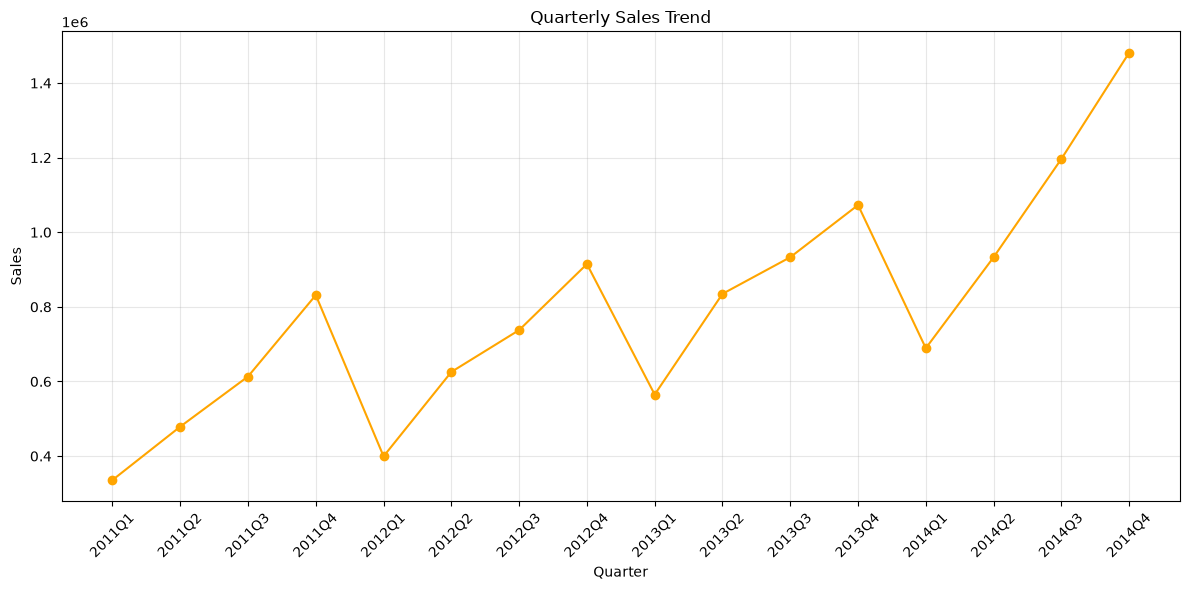

In [ ]:
df['Quarter'] = df['Order.Date'].dt.to_period('Q')

quarterly_sales = (
    df.groupby('Quarter')['Sales']
      .sum()
      .reset_index()
)

quarterly_sales['Quarter'] = quarterly_sales['Quarter'].astype(str)

plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales['Quarter'],quarterly_sales['Sales'],marker='o',color='orange'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

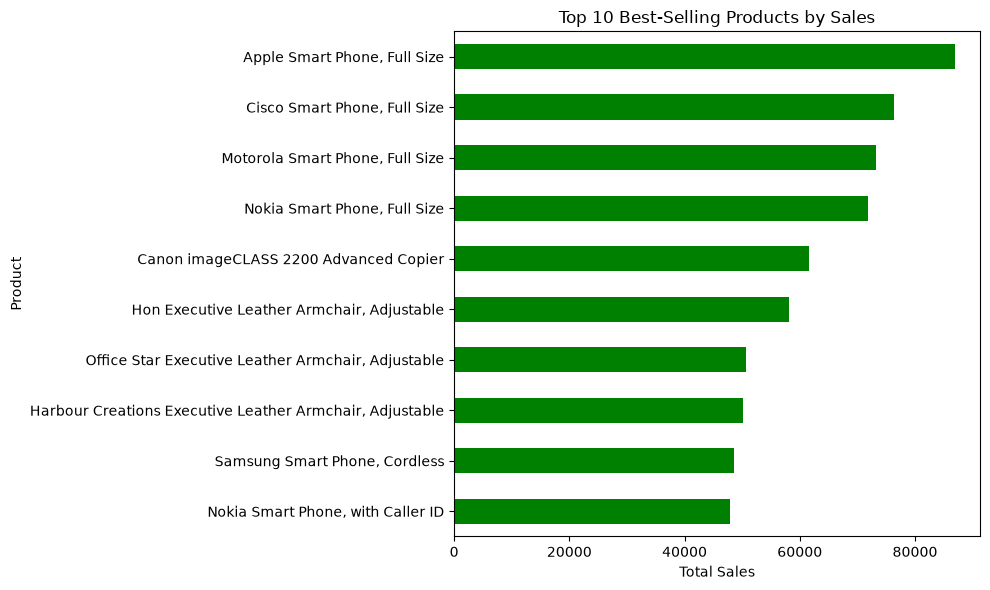

In [17]:
top_products = (
    df.groupby('Product.Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))

top_products.plot(kind='barh',color='green')

plt.title('Top 10 Best-Selling Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

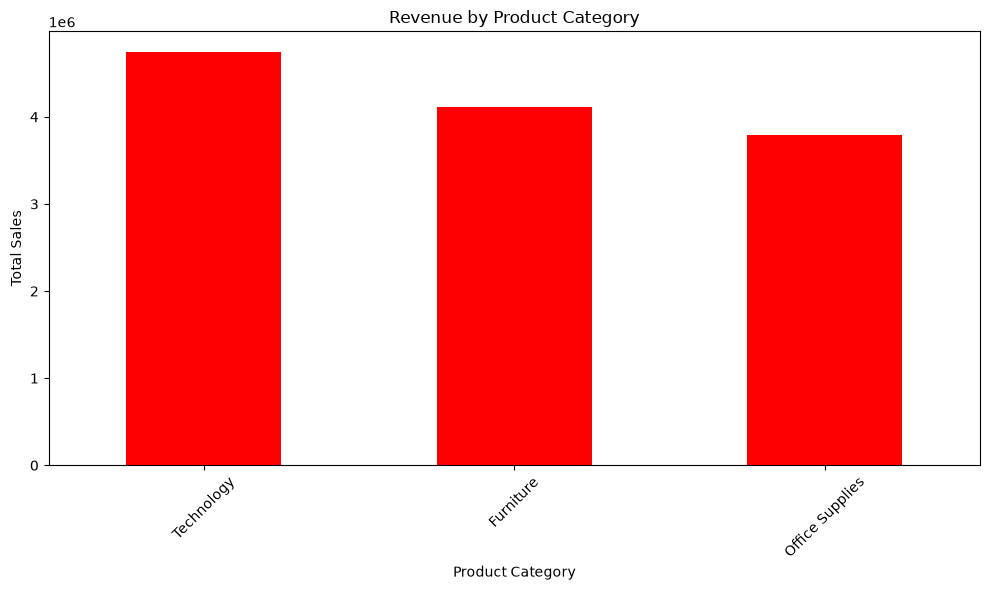

In [ ]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_sales.plot(kind='bar',color ='red')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

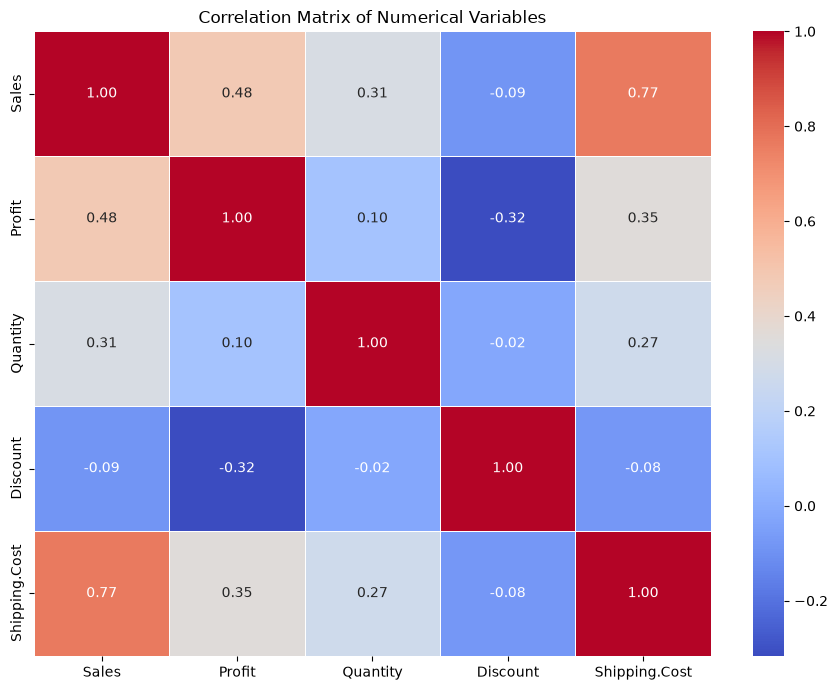

In [21]:
numeric_cols = [
    'Sales',
    'Profit',
    'Quantity',
    'Discount',
    'Shipping.Cost'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

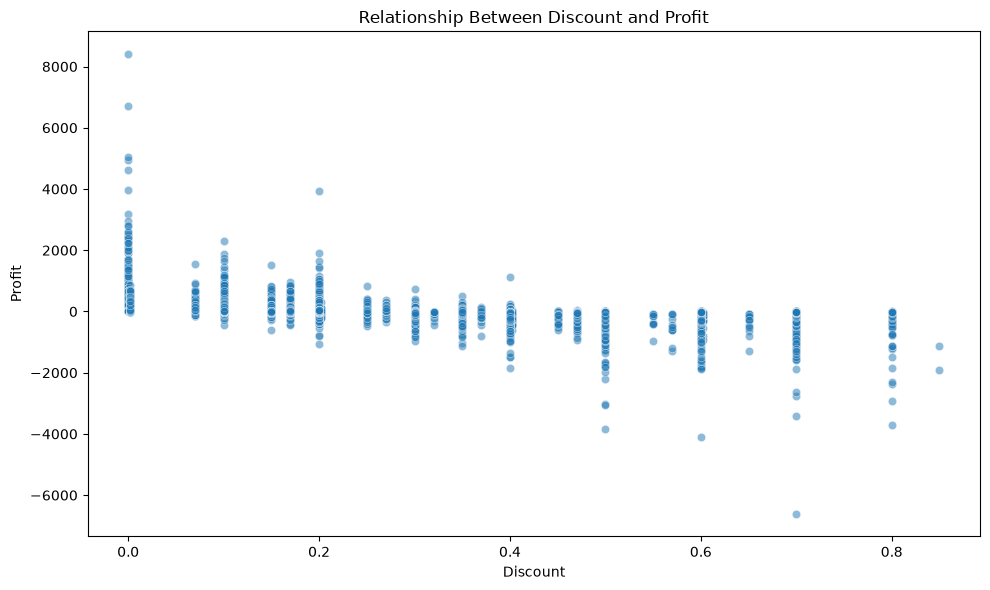

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.5
)

plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()